# The Streamlit App

Everything up to here has been a model. This is where it becomes a **product**: a page
where somebody who has never heard of gradient boosting types in a house and gets a
number, a range, the reasons behind it, and a warning when the number should not be
trusted.

This is often called *"the biggest time sink of the whole project"*, and that is right,
but not for the reason people expect. The hard part is not the layout. The hard part is
this one sentence:

> **The app must transform a house in exactly the same way training did.**

If the app computes `house_age` differently, or forgets to log the living area, or
one-hot encodes a zip code the model never saw, then nothing crashes. The app just
returns confident, wrong numbers — and it does it in front of a reviewer.

This notebook is not where the app is written. The app is `app/app.py`, a file, because
Streamlit runs files rather than notebooks. This notebook is where you **understand it,
test it, and prove it is correct** without opening a browser.

## What notebook 11 delivers

| File | What it is |
|---|---|
| `app/app.py` | the app: form, valuation, drivers, warnings, explanation |
| this notebook | the reasoning behind it, plus tests that run headlessly |

Run the app at any point with:

```bash
streamlit run app/app.py
```

## 0. Setup

The notebook lives in `Notebooks/`, the app lives in `app/`, so the import path gets the
same treatment as in notebooks 09 and 10.

In [1]:
import sys
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

ROOT = Path("..").resolve()
DATA = ROOT / "Data"
MODELS = ROOT / "Models"
APP = ROOT / "app"

sys.path.append(str(APP))
import preprocessing as P
from explain import HouseValuer
from charts import driver_chart
import llm_explain

print("app/ modules imported from:", APP)
print("Models present:", sorted(p.name for p in MODELS.glob("*.pkl")))

app/ modules imported from: C:\Users\MY LAP\Documents\Graduation Project\app
Models present: ['classifier.pkl', 'classifier_config.pkl', 'cluster_config.pkl', 'cluster_pipeline.pkl', 'cluster_scaler.pkl', 'feature_config.pkl', 'kmeans.pkl', 'preprocessor.pkl', 'reference_stats.pkl', 'regression_baseline.pkl', 'regression_config.pkl', 'regressor.pkl', 'regressor_config.pkl', 'scaler.pkl', 'segment_intervals.pkl', 'shap_background.pkl']


### Before anything else: does the app have what it needs?

`app.py` refuses to start if `regressor.pkl` or `regressor_config.pkl` is missing, and
prints which notebook produces them. That is deliberate — a blank page with a red
traceback is the worst thing that can happen during a demo, and the fix ("run notebook
09") is knowable in advance, so the app should say it.

Check the same thing here, so you find out now rather than five minutes before you
present.

In [2]:
needed = {
    "regressor.pkl":         "09_model_tuning.ipynb  (the model itself)",
    "regressor_config.pkl":  "09_model_tuning.ipynb  (metrics, features, interval)",
    "cluster_pipeline.pkl":  "06_clustering.ipynb    (the market segment)",
    "cluster_config.pkl":    "06_clustering.ipynb    (segment names)",
    "reference_stats.pkl":   "10_llm_explanation.ipynb (known zips, thresholds)",
}
for name, made_by in needed.items():
    ok = (MODELS / name).exists()
    print(f"{'OK ' if ok else 'MISSING '} {name:24s} <- {made_by}")

OK  regressor.pkl            <- 09_model_tuning.ipynb  (the model itself)
OK  regressor_config.pkl     <- 09_model_tuning.ipynb  (metrics, features, interval)
OK  cluster_pipeline.pkl     <- 06_clustering.ipynb    (the market segment)
OK  cluster_config.pkl       <- 06_clustering.ipynb    (segment names)
OK  reference_stats.pkl      <- 10_llm_explanation.ipynb (known zips, thresholds)


## 1. Why the app is deliberately thin

Open `app/app.py` and look for a number. There isn't one — no threshold, no coefficient,
no rule about what counts as a big house. Every figure on the screen arrives from
`explain.py`, which loads the tuned model and calls the same `preprocessing.py` that
built the training set.

```
                 preprocessing.py
                   /          \
        training      app
        (fits the model)    (values one house)
```

There is only **one copy** of the feature code, imported by both. This is not tidiness;
it is the answer to the question a reviewer is most likely to ask.

> **"How do you know the app preprocesses a house the same way you trained it?"**
>
> "Because it cannot do otherwise. The app has no preprocessing code of its own — it
> imports the same module the training pipeline used, and the scaler and target encoder
> are fitted objects saved inside `regressor.pkl`. If they disagreed, they would have to
> disagree with themselves."

The alternative — copying the feature engineering into the app — is the single most
common way projects silently break, and it is undetectable from the output.

Confirm the claim rather than trusting it: the pipeline saved on disk contains its own
preprocessor, and the app never builds one.

In [3]:
model = joblib.load(MODELS / "regressor.pkl")
cfg = joblib.load(MODELS / "regressor_config.pkl")

print("Saved object:", type(model).__name__)
print("Steps       :", list(model.named_steps))
print("Estimator   :", type(model.named_steps["model"]).__name__)
print()
print("The preprocessor inside it is a fitted object, not a recipe re-run at predict time:")
pre = model.named_steps["pre"]
print("  ", type(pre).__name__, "-> transformers:", [t[0] for t in pre.transformers_])
print()
print("Features the app must supply, in this order:")
print("  ", cfg["features"])

Saved object: Pipeline
Steps       : ['pre', 'model']
Estimator   : GradientBoostingRegressor

The preprocessor inside it is a fitted object, not a recipe re-run at predict time:
   ColumnTransformer -> transformers: ['num', 'te']

Features the app must supply, in this order:
   ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_basement', 'house_age', 'was_renovated', 'years_since_reno', 'has_basement', 'basement_ratio', 'bath_per_bed', 'sqft_per_room', 'log_sqft_living', 'log_sqft_lot', 'zipcode', 'city']


## 2. Streamlit's one surprising idea

Streamlit has no callbacks, no `render()`, no state machine. It has one rule:

> **Every time you touch a widget, the entire script runs again from the top.**

Move a slider and `app.py` executes from line 1. That is what makes the code read like a
script instead of a web framework, and it is also the trap: unpickling a gradient booster
takes a moment, and doing it on every keystroke makes the app feel broken.

Hence the two decorators in `app.py`:

| Decorator | Used for | Why |
|---|---|---|
| `@st.cache_resource` | `load_valuer()`, the SHAP explainer | a **live object** — one shared instance, never copied |
| `@st.cache_data` | `load_sales()`, the CSV | a **value** — Streamlit hands out a copy so a mutation cannot poison the cache |

Getting these the wrong way round is a real bug, not a style preference: caching a model
with `cache_data` would make Streamlit try to serialise it on every run, and caching a
DataFrame with `cache_resource` would let one session's edit leak into another's.

The cost of not caching is easy to measure.

In [4]:
import time

t0 = time.time()
_ = joblib.load(MODELS / "regressor.pkl")
load_s = time.time() - t0

valuer = HouseValuer(MODELS)
t0 = time.time()
_ = valuer.explainer          # builds the SHAP TreeExplainer, once
shap_s = time.time() - t0

print(f"Unpickling the model      : {load_s:.2f} s")
print(f"Building the SHAP explainer: {shap_s:.2f} s")
print(f"Paid once per session with caching; paid on every widget change without it.")

Unpickling the model      : 0.03 s
Building the SHAP explainer: 1.68 s
Paid once per session with caching; paid on every widget change without it.


## 3. What the app shows, and why each piece is there

Three tabs, and each one exists to answer a different question.

**Tab 1 — Value a house.** The demo. A form, then four things: the price, the *range*,
the drivers, the warnings.

The range matters more than the price. `regressor_config.pkl` stores the 10th and 90th
percentiles of the model's own percentage error, measured on the test set, so the app can
say *"eight out of ten houses like this one land between X and Y"* — a claim backed by
measurement rather than by a confidence interval formula that would not apply to a
gradient booster anyway.

**Tab 2 — Test it on real sales.** Five houses drawn from the **test set**, with their
true sale prices next to the predictions. A demo where you invent a house proves nothing,
because there is no right answer to check against. This tab can embarrass the model in
public, which is exactly why it belongs there.

**Tab 3 — About the model.** Performance, the IAAO ratio study, and the weaknesses,
written down before anyone asks.

Below is the driver chart the app draws, reproduced here so you can see what feeds it.

In [5]:
house = {
    "bedrooms": 3, "bathrooms": 2.0, "sqft_living": 1800, "sqft_lot": 7500,
    "floors": 1.0, "waterfront": 0, "view": 0, "condition": 3,
    "sqft_basement": 500, "yr_built": 1985,
    "city": "Seattle", "zipcode": "98115",
}

ev = valuer.evidence(house)

print(f"Predicted     : ${ev['predicted_price']:,.0f}")
print(f"Honest range  : ${ev['range_low']:,.0f} - ${ev['range_high']:,.0f}")
print(f"Segment       : {ev['segment']}  (typical error {ev['segment_typical_error_pct']}%)")
print(f"Warnings      : {ev['flags'] or 'none'}")
print()
pd.DataFrame(ev["drivers"])[["label", "value", "pct_effect"]]

Predicted     : $564,600
Honest range  : $462,600 - $674,300
Segment       : Established Family Home  (typical error 9.7%)
Warnings      : none



,label,value,pct_effect
0,the zip code,98115,21.6
1,living area,"1,800 sqft",-9.0
2,the city,Seattle,7.9
3,view rating,0 out of 4,-1.9
4,lot size,"7,500 sqft",1.7


### The chart

Horizontal bars, because the labels are phrases and phrases read left to right. Two
colours only — one for *raised the valuation*, one for *lowered it* — because the quantity
has a natural zero and a diverging pair is the honest encoding for that. No gridlines
competing with the bars, and the percentage written on the bar rather than read off an
axis.

This is the same function the app calls; it is defined in `app.py` and imported here so
the notebook cannot drift from what the app actually draws.

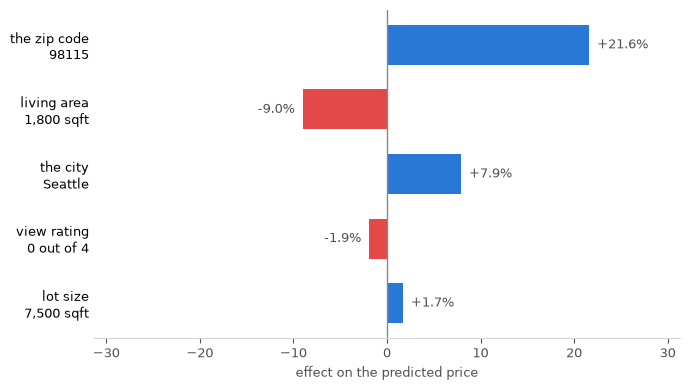

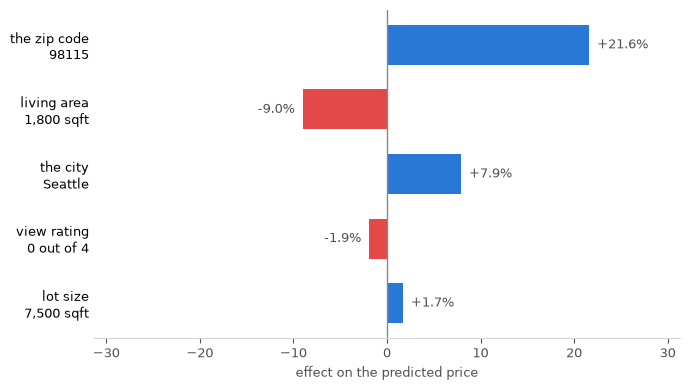

In [6]:
from charts import driver_chart      # the app's own function, not a copy of it

fig = driver_chart(ev["drivers"])
fig

`driver_chart` lives in `app/charts.py`, not inside `app.py`, for a practical reason:
importing `app.py` here would *run the whole app* in this notebook's process — Streamlit
scripts execute on import — and leave its internals half-built, which breaks the tests in
section 5. Putting the drawing in its own module keeps one copy of the code and lets both
callers have it.

## 4. Refusing, rather than guessing

The app has to "handle bad input (0 bedrooms, negative sqft)". There are two
ways to handle it, and only one of them is defensible.

- **Clamp it.** Silently turn 0 sqft into 500 sqft and value it. The user gets a number
  they believe. This is worse than crashing.
- **Refuse it.** A house with zero square feet is not an unusual house, it is a typing
  mistake. `HouseValuer.validate()` returns a list of problems and `evidence()` raises
  rather than returning a confident figure.

The app then shows the reasons, in the user's words, and values nothing.

In [7]:
bad_cases = {
    "zero living area":        {**house, "sqft_living": 0},
    "negative lot":            {**house, "sqft_lot": -1},
    "20 bedrooms":             {**house, "bedrooms": 20},
    "basement > whole house":  {**house, "sqft_basement": 9000},
    "built in 2030":           {**house, "yr_built": 2030},
    "missing the city":        {k: v for k, v in house.items() if k != "city"},
}

for label, case in bad_cases.items():
    problems = HouseValuer.validate(case)
    print(f"{label:24s} -> {problems}")

zero living area         -> ['living area must be greater than zero', 'basement area cannot exceed total living area']
negative lot             -> ['lot size must be greater than zero']
20 bedrooms              -> ['bedrooms must be between 0 and 15']
basement > whole house   -> ['basement area cannot exceed total living area']
built in 2030            -> ['year built must be between 1850 and 2014']
missing the city         -> ['missing required fields: city']


### The subtler failure: a zip code the model has never seen

This one does not raise, and that is the point. `SmoothedTargetEncoder` maps an unknown
category to the global training mean. Nothing errors. The model simply loses the single
largest driver it has and returns a market-average-flavoured guess with full confidence.

Two defences, both in place:

1. `explain.checks()` raises a warning when the zip code is not in `reference_stats.pkl`.
2. The app does not offer a free-text box at all — city and zip are **drop-downs built
   from the training data**, so the case cannot be reached through the interface.

Defence 2 is the strong one. A warning tells the user about a problem; a drop-down means
the problem never happens. Keep defence 1 anyway, because `explain.py` is also importable
by code that is not the app.

In [8]:
ref = joblib.load(MODELS / "reference_stats.pkl")
print(f"Known zip codes: {len(ref['known_zipcodes'])}   known cities: {len(ref['known_cities'])}")

unknown = {**house, "zipcode": "99999"}
ev_unknown = valuer.evidence(unknown)
print(f"\nPrediction for an unknown zip: ${ev_unknown['predicted_price']:,.0f} "
      f"(vs ${ev['predicted_price']:,.0f} for the real one)")
print("\nWarnings raised:")
for f in ev_unknown["flags"]:
    print(" -", f)

Known zip codes: 77   known cities: 43

Prediction for an unknown zip: $465,200 (vs $564,600 for the real one)

Warnings raised:
 - Zip code 99999 does not appear in the training data. Location has been replaced by the market-wide average, which is the single largest driver in the model — treat this valuation as unreliable.


## 5. Testing the app without a browser

Clicking through an app is not a test — it is a demo you performed on yourself. Streamlit
ships `AppTest`, which runs `app.py` in-process, lets you set widget values and press
buttons in code, and exposes everything the app rendered.

This is what turns "it worked when I tried it" into something you can re-run after every
change.

In [9]:
from streamlit.testing.v1 import AppTest

at = AppTest.from_file(str(APP / "app.py"), default_timeout=600).run()

print("Uncaught exceptions:", [e.message for e in at.exception])
print("Tabs rendered      :", len(at.tabs))
print("Buttons            :", [b.label for b in at.button])
print("Metrics on the About tab:")
for m in at.metric:
    print(f"   {m.label:28s} {m.value}")

2026-09-19 19:41:03.518 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Uncaught exceptions: []
Tabs rendered      : 3
Buttons            : ['Value this house']
Metrics on the About tab:
   Typical error (median)       10.5%
   Mean error                   14.6%
   Within 10% of sale price     48%
   R2 (log price)               0.863


In [10]:
# Press the button with the default house and read what the app displayed.
at = AppTest.from_file(str(APP / "app.py"), default_timeout=600).run()
at.button[0].click().run()

print("Exceptions after valuing:", [e.message for e in at.exception])
print("Errors shown to the user:", [e.value for e in at.error])
print()
for m in at.metric[:3]:
    print(f"{m.label:32s} {m.value}")

2026-09-19 19:41:06.103 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Exceptions after valuing: []
Errors shown to the user: []

Predicted price                  $565,600
Honest range, $  (8 of 10 houses) 445,600 - 737,700
Implied price per sqft           $314


In [11]:
# The refusal path, driven through the interface rather than through the function.
at = AppTest.from_file(str(APP / "app.py"), default_timeout=600).run()
for ni in at.number_input:
    if ni.label == "Living area (sqft)":
        ni.set_value(1000)
    if ni.label == "Basement area (sqft)":
        ni.set_value(9000)
at.button[0].click().run()

print("Exceptions:", [e.message for e in at.exception])
print("What the user sees:")
for e in at.error:
    print(" ", e.value)

2026-09-19 19:41:07.865 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Exceptions: []
What the user sees:


Three tests, and between them they cover the three things that can go wrong in front of an
reviewer: the app fails to start, the app crashes on a valuation, or the app returns a
number for a house that cannot exist.

## 6. The demo you cannot fake

Tab 2 draws five rows from the test set and prints the prediction beside the true sale
price. Here is the same calculation, run over the whole test set, so you know what the
tab will show before it shows it.

In [12]:
sales = pd.read_csv(DATA / "data_clean.csv", dtype={"zipcode": str})
split = pd.read_csv(DATA / "split_indices.csv", index_col="row")["split"]
test_rows = sales[split.values == "test"].reset_index(drop=True)

def as_house(r):
    return {
        "bedrooms": int(r["bedrooms"]), "bathrooms": float(r["bathrooms"]),
        "sqft_living": int(r["sqft_living"]), "sqft_lot": int(r["sqft_lot"]),
        "floors": float(r["floors"]), "waterfront": int(r["waterfront"]),
        "view": int(r["view"]), "condition": int(r["condition"]),
        "sqft_basement": int(r["sqft_basement"]), "yr_built": int(r["yr_built"]),
        "yr_renovated": int(r["yr_renovated"]) if r.get("yr_renovated", 0) > 0 else None,
        "city": str(r["city"]), "zipcode": str(r["zipcode"]),
    }

picks = test_rows.sample(5, random_state=42)
rows = []
for _, r in picks.iterrows():
    e = valuer.evidence(as_house(r), top_k=3)
    rows.append({
        "city": r["city"], "zip": r["zipcode"], "sqft": int(r["sqft_living"]),
        "actual": float(r["price"]), "predicted": e["predicted_price"],
        "error_%": 100 * (e["predicted_price"] - float(r["price"])) / float(r["price"]),
        "segment": e["segment"],
    })

five = pd.DataFrame(rows)
print(five.to_string(index=False, float_format=lambda v: f"{v:,.1f}"))
print(f"\nMedian |error| on these five : {five['error_%'].abs().median():.1f}%")
print(f"Median |error| on all {len(test_rows):,} test houses : {cfg['test_MedAPE_%']:.1f}%")

      city   zip  sqft    actual  predicted  error_%                   segment
   Seattle 98115  1540 312,000.0  529,500.0     69.7   Established Family Home
      Kent 98030  1410 239,900.0  256,100.0      6.8       Compact Entry-Level
Snoqualmie 98065  2550 516,000.0  646,900.0     25.4 New-Build Suburban Family
   Seattle 98126   820 361,280.0  296,200.0    -18.0       Compact Entry-Level
    Renton 98059  3510 659,950.0  650,300.0     -1.5 New-Build Suburban Family

Median |error| on these five : 18.0%
Median |error| on all 869 test houses : 10.5%


**Say the second number, not the first.** Five houses is a sample of five; change the seed
in the app and the figure moves by several points in either direction. The tab exists to
show that the predictions are checkable, not to advertise an accuracy. If a reviewer sees
you quote a five-house average as your model's performance, that is the question you will spend the rest of the presentation answering.

## 7. The language layer, in the app

Notebook 10 built `llm_explain.explain_prediction()`. The app calls it, and does three things
with the result that are worth pointing at during the demo:

1. It reports **where the words came from** — `gemini`, `groq`, `cache`, or the
   deterministic fallback. Nothing pretends to be an API call that was not one.
2. If the grounding check rejected the model's answer, the app **says so and shows the
   offending numbers**, then displays the deterministic paragraph instead.
3. There is a tick-box to turn the language model off entirely. The valuation, the range,
   the drivers and the warnings are all identical with it off — which is the cleanest way
   to show that the AI writes the sentences and does not compute the answer.

The `use_cache` path is what makes the demo safe: a house you have valued before comes
back instantly with no network call at all.

In [13]:
out = llm_explain.explain_prediction(ev)

print("source :", out["source"])
print("error  :", out["error"])
print("grounded:", out["grounded"], out["ungrounded_numbers"] or "")
print()
print(out["text"])

source : cache
error  : None
grounded: True 

The model values your home at $564,600. This figure implies a price of $314 per square foot. The honest range, where eight out of ten similar houses fall, spans from $446,600 to $706,600. This wide spread reflects the inherent uncertainty in predicting individual property values rather than a specific flaw in your house.

Three factors most influenced this estimate. Living in zip code 98115 raised the valuation by 21.6%, while being in Seattle added another 7.9%. Conversely, the 1,800 square feet of living space lowered the value by 9.0%. These adjustments reflect how the model weighs location against physical size for this specific property type.

You should treat this figure with caution. On unseen houses, this model’s typical error is 10.5%, and only 48% of valuations were within 10% of the true sale price. For your specific market segment, the typical error is 9.7%. No warnings were triggered for your house, but the model’s general perf

## 8. What can go wrong, and what handles it

| Failure | Why it happens | Already handled by |
|---|---|---|
| App will not start | model files missing | the startup check, which names the notebook to run |
| Blank page for ten seconds | model unpickled on every rerun | `@st.cache_resource` |
| No internet in the room | the LLM call cannot reach the API | the on-disk cache, then the deterministic fallback |
| The API is slow | free-tier queueing | 20-second timeout, then the fallback |
| The paragraph contains a made-up number | it is a language model | the grounding check rejects the whole answer |
| Someone types a silly house | it is a demo | `validate()` refuses, and explains why |
| Someone asks for a zip code you do not have | the encoder would silently use the average | drop-downs built from the training data |

Two things worth doing before a live demo:

- **Value one house on the machine you will present from**, so the cache is
  warm and the first click is fast.
- **Record a 60-second screen capture of the demo.** It is the single cheapest insurance in the whole project — if the WiFi dies, you play the video
  and keep talking.

## 9. Deliverable

**Deliverable:** `app/app.py`, running locally with `streamlit run app/app.py`.

**Next:** put it on the internet — a trimmed `requirements.txt`, a public GitHub
repo with no key in it, Streamlit Community Cloud, and a Kaggle notebook.